# Explore Average Shower Data — AllShowers Point Cloud

Loads `cashed_showers_2000.pt` (saved by `save_output` from `allshowers.generate_showers`).

Data format:
- `samples`    — `(N, max_pts, 5)` float32: columns = **x, y, layer_idx, energy, time**
- `energies`   — `(N, 1)` float32: primary particle energy [GeV]
- `directions` — `(N, 3)` float32: CORSIKA unit vector [sin θ cos φ, sin θ sin φ, cos θ]
- `labels`     — `(N,)`   int32: particle class

Valid hits per shower: rows where `energy > 0`.

## 1. Imports & Data Loading

In [28]:
import os, sys
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# ── Path to the cached file ───────────────────────────────────────────────────
CACHE_FILE = "/n/home05/zdimitrov/tambo/TambOpt/detector_optimization_v2/cashed_showers_2000.pt"
NUM_LAYERS = 24

# ── Load ─────────────────────────────────────────────────────────────────────
# save_output uses showerdata.Showers.save() → HDF5 (even with .pt extension).
# Fall back to torch.load if showerdata is not available.
def load_cache(path):
    try:
        import showerdata
        sh = showerdata.load(path)
        # showerdata.Showers stores hits as variable-length arrays; stack into (N, max_pts, ncols)
        all_pts = [torch.from_numpy(np.array(s.points, dtype=np.float32)) for s in sh]
        ncols   = all_pts[0].shape[-1] if all_pts[0].ndim > 1 else 5
        max_pts = max(p.reshape(-1, ncols).shape[0] for p in all_pts)
        samples = torch.zeros(len(sh), max_pts, ncols)
        for i, p in enumerate(all_pts):
            pts = p.reshape(-1, ncols)
            samples[i, :pts.shape[0]] = pts
        energies   = torch.tensor([sh[i].energies   for i in range(len(sh))], dtype=torch.float32).unsqueeze(1)
        directions = torch.tensor([sh[i].directions for i in range(len(sh))], dtype=torch.float32)
        labels     = torch.tensor([sh[i].pdg       for i in range(len(sh))], dtype=torch.int32)
        print("Loaded via showerdata")
        return samples, energies, directions, labels
    except Exception as e_sh:
        print(f"showerdata load failed ({e_sh}), trying torch.load ...")
    data       = torch.load(path, map_location="cpu", weights_only=False)
    print("Loaded via torch.load")
    return data["samples"], data["energies"], data["directions"], data["labels"]

samples, energies, directions, labels = load_cache(CACHE_FILE)

N        = samples.shape[0]
max_pts  = samples.shape[1]
n_cols   = samples.shape[2]
with_time = n_cols >= 5

# Convenience slices
pts_x   = samples[:, :, 0]   # (N, max_pts)
pts_y   = samples[:, :, 1]
pts_lyr = samples[:, :, 2].long()
pts_e   = samples[:, :, 3]
pts_t   = samples[:, :, 4] if with_time else None
valid   = pts_e > 0           # (N, max_pts) — True for real hits

p_energy = energies.view(N)  # (N,)


Loaded via showerdata


In [29]:
# Unpack CORSIKA direction vector → zenith θ and azimuth φ
nx = directions[:, 0, 0]  # sin θ cos φ
ny = directions[:, 0, 1]  # sin θ sin φ
nz = directions[:, 0, 2]  # cos θ
zenith  = torch.acos(nz.clamp(-1, 1))           # θ  [rad]
azimuth = torch.atan2(ny, nx)                   # φ  [rad]
sin_z   = torch.sin(zenith)
cos_z   = torch.cos(zenith)
sin_a   = torch.sin(azimuth)
cos_a   = torch.cos(azimuth)

hits_per_shower = valid.sum(dim=1).float()  # (N,)

print(f"\nN showers       : {N}")
print(f"max_pts         : {max_pts}")
print(f"columns         : {'x, y, layer, energy, time' if with_time else 'x, y, layer, energy'}")
print(f"Energy range    : [{p_energy.min():.2e}, {p_energy.max():.2e}] GeV")
print(f"Zenith range    : [{zenith.min().item():.2f}, {zenith.max().item():.2f}] rad  ({np.degrees(zenith.min().item()):.1f}–{np.degrees(zenith.max().item()):.1f} deg)")
print(f"Hits per shower : min={hits_per_shower.min():.0f}, mean={hits_per_shower.mean():.0f}, max={hits_per_shower.max():.0f}")
print(f"Labels          : {labels.unique().tolist()}")


N showers       : 2000
max_pts         : 2048
columns         : x, y, layer, energy, time
Energy range    : [1.00e+05, 9.98e+07] GeV
Zenith range    : [1.05, 1.74] rad  (60.0–100.0 deg)
Hits per shower : min=1044, mean=1992, max=2019
Labels          : [0, 1]


## 2. Primary Parameter Distributions

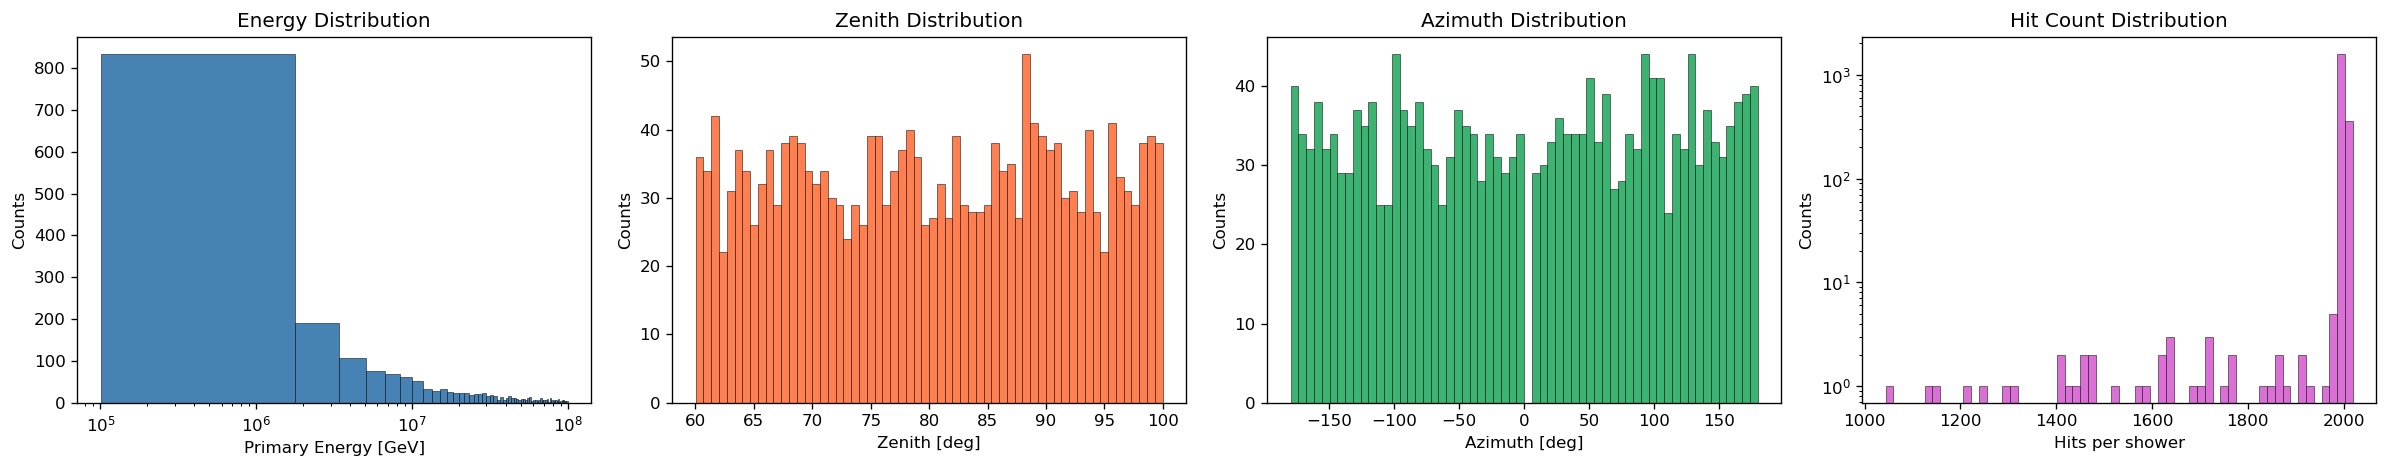

In [ ]:
zenith_deg  = np.degrees(zenith.numpy())
azimuth_deg = np.degrees(azimuth.numpy())

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].hist(p_energy.numpy(), bins=60, color='steelblue', edgecolor='k', lw=0.3)
axes[0].set_xscale('log'); axes[0].set_xlabel('Primary Energy [GeV]')
axes[0].set_title('Energy Distribution')

axes[1].hist(zenith_deg, bins=60, color='coral', edgecolor='k', lw=0.3)
axes[1].set_xlabel('Zenith [deg]'); axes[1].set_title('Zenith Distribution')

axes[2].hist(azimuth_deg, bins=60, color='mediumseagreen', edgecolor='k', lw=0.3)
axes[2].set_xlabel('Azimuth [deg]'); axes[2].set_title('Azimuth Distribution')

axes[3].hist(hits_per_shower.numpy(), bins=60, color='orchid', edgecolor='k', lw=0.3)
axes[3].set_xlabel('Hits per shower'); axes[3].set_title('Hit Count Distribution')
axes[3].set_yscale('log')


for ax in axes: ax.set_ylabel('Counts')
plt.tight_layout(); plt.show()

## 3. Longitudinal Profile — Mean Energy per Layer

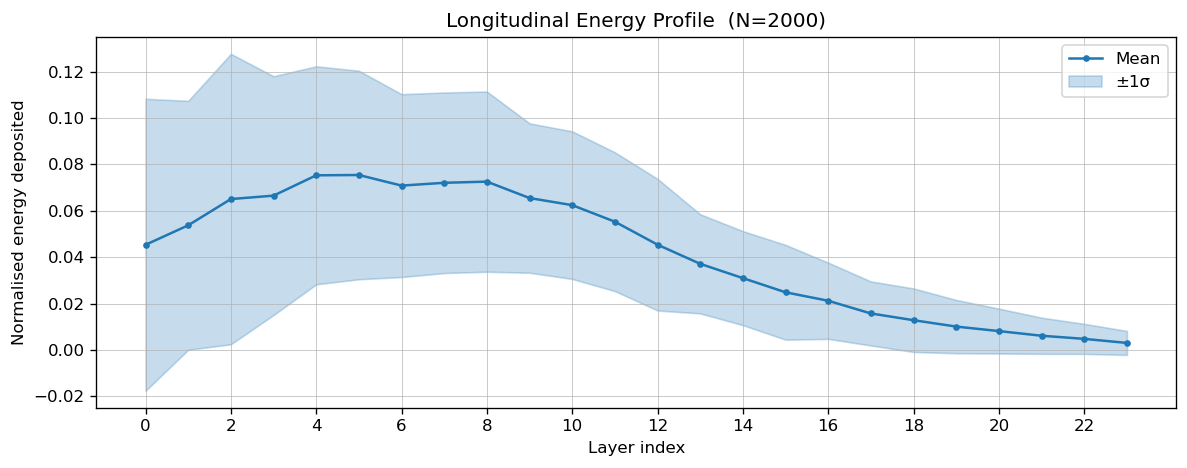

In [31]:
# Energy deposited per layer per shower
elayer = torch.zeros(N, NUM_LAYERS)   # (N, 24)
for i in range(N):
    lyr = pts_lyr[i][valid[i]].clamp(0, NUM_LAYERS - 1)
    e   = pts_e[i][valid[i]]
    elayer[i].scatter_add_(0, lyr, e)

# Normalise per shower
etotal = elayer.sum(1, keepdim=True).clamp(min=1e-30)
elayer_norm = elayer / etotal

mean_lyr = elayer_norm.mean(0).numpy()
std_lyr  = elayer_norm.std(0).numpy()
layers   = np.arange(NUM_LAYERS)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(layers, mean_lyr, marker='o', ms=3, lw=1.5, color='C0', label='Mean')
ax.fill_between(layers, mean_lyr - std_lyr, mean_lyr + std_lyr, alpha=0.25, color='C0', label='±1σ')
ax.set_xlabel('Layer index'); ax.set_ylabel('Normalised energy deposited')
ax.set_title(f'Longitudinal Energy Profile  (N={N})')
ax.set_xticks(layers[::2]); ax.legend(); ax.grid(lw=0.4)
plt.tight_layout(); plt.show()

## 4. Individual Shower Visualizations
Show hit scatter plots for 5 showers, coloured by energy.

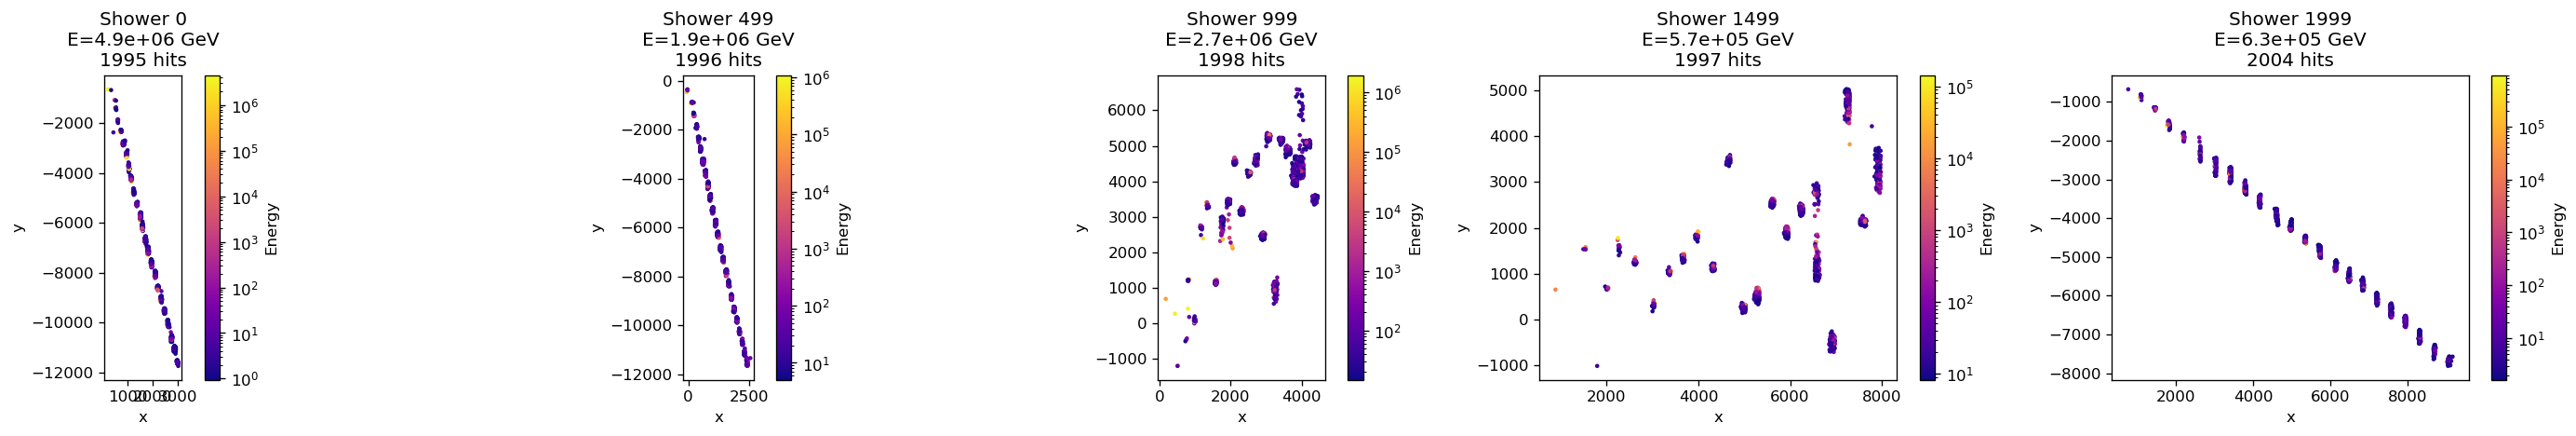

In [32]:
n_show = 5
show_idx = np.linspace(0, N - 1, n_show, dtype=int)

fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 4))
for col, idx in enumerate(show_idx):
    mask = valid[idx]
    x = pts_x[idx][mask].numpy()
    y = pts_y[idx][mask].numpy()
    e = pts_e[idx][mask].numpy()
    lyr = pts_lyr[idx][mask].numpy()
    sc = axes[col].scatter(x, y, c=e, cmap='plasma', s=3,
                           norm=mcolors.LogNorm(vmin=max(e.min(), 1e-10), vmax=e.max()))
    fig.colorbar(sc, ax=axes[col], label='Energy')
    axes[col].set_xlabel('x'); axes[col].set_ylabel('y')
    axes[col].set_title(f'Shower {idx}\nE={p_energy[idx]:.1e} GeV\n{mask.sum()} hits')
    axes[col].set_aspect('equal')
plt.tight_layout(); plt.show()

## 5. Average 2-D Shower on a Common Grid
Bin all valid hits onto a common 64×64 x–y grid and compute mean energy density.

x range: [-12223.5, 13666.9]   y range: [-12331.5, 13901.6]


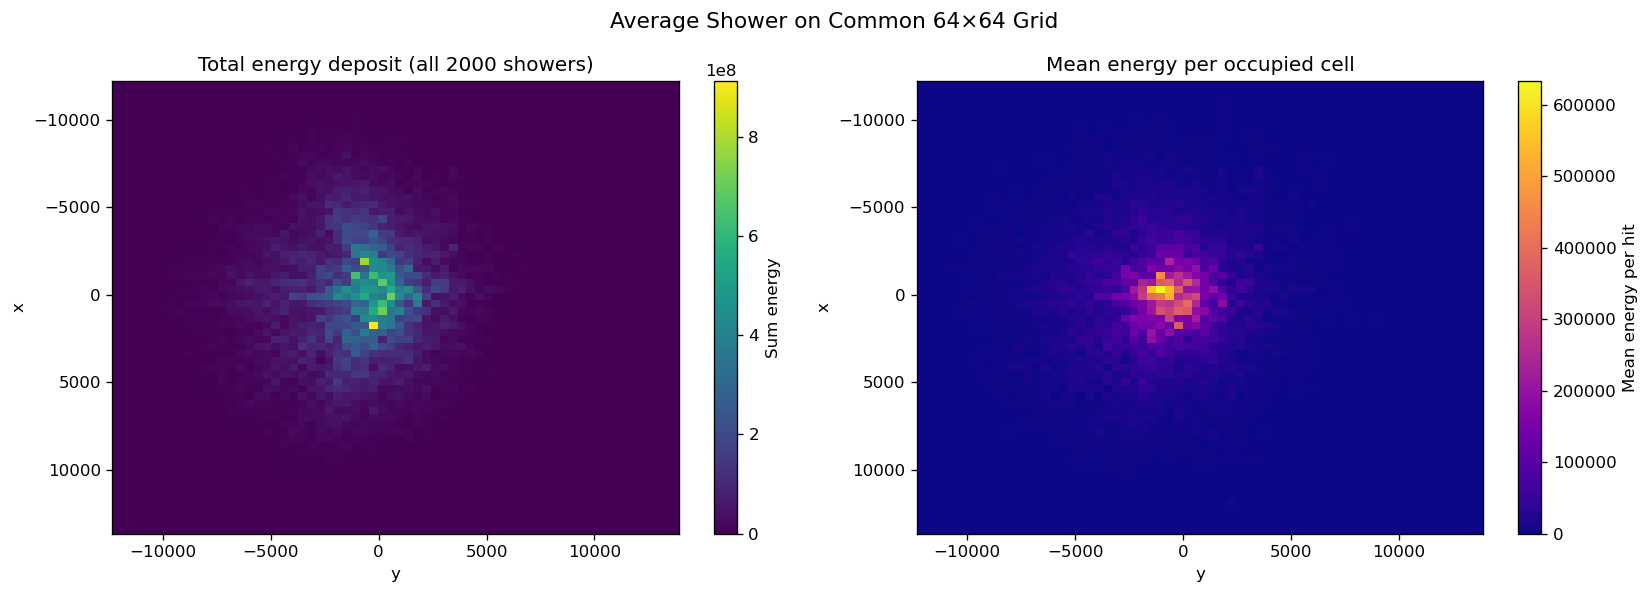

In [33]:
GRID_RES = 64

# Collect all valid hits
all_x = pts_x[valid].numpy()
all_y = pts_y[valid].numpy()
all_e = pts_e[valid].numpy()
all_t = pts_t[valid].numpy() if with_time else None

x_lo, x_hi = float(all_x.min()), float(all_x.max())
y_lo, y_hi = float(all_y.min()), float(all_y.max())
print(f"x range: [{x_lo:.1f}, {x_hi:.1f}]   y range: [{y_lo:.1f}, {y_hi:.1f}]")

# 2D histogram of total energy (sum)
h_e, xe, ye = np.histogram2d(all_x, all_y,
                              bins=GRID_RES,
                              range=[[x_lo, x_hi], [y_lo, y_hi]],
                              weights=all_e)
h_n, _, _  = np.histogram2d(all_x, all_y,
                              bins=GRID_RES,
                              range=[[x_lo, x_hi], [y_lo, y_hi]])
mean_e_grid = h_e / np.maximum(h_n, 1)

extent = [y_lo, y_hi, x_hi, x_lo]   # imshow: [left, right, bottom, top]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(h_e, extent=extent, aspect='auto', origin='upper', cmap='viridis')
fig.colorbar(im0, ax=axes[0], label='Sum energy')
axes[0].set_title(f'Total energy deposit (all {N} showers)')
axes[0].set_xlabel('y'); axes[0].set_ylabel('x')

im1 = axes[1].imshow(mean_e_grid, extent=extent, aspect='auto', origin='upper', cmap='plasma')
fig.colorbar(im1, ax=axes[1], label='Mean energy per hit')
axes[1].set_title('Mean energy per occupied cell')
axes[1].set_xlabel('y'); axes[1].set_ylabel('x')

plt.suptitle(f'Average Shower on Common {GRID_RES}×{GRID_RES} Grid', fontsize=13)
plt.tight_layout(); plt.show()

## 6. Per-Layer Average Shower

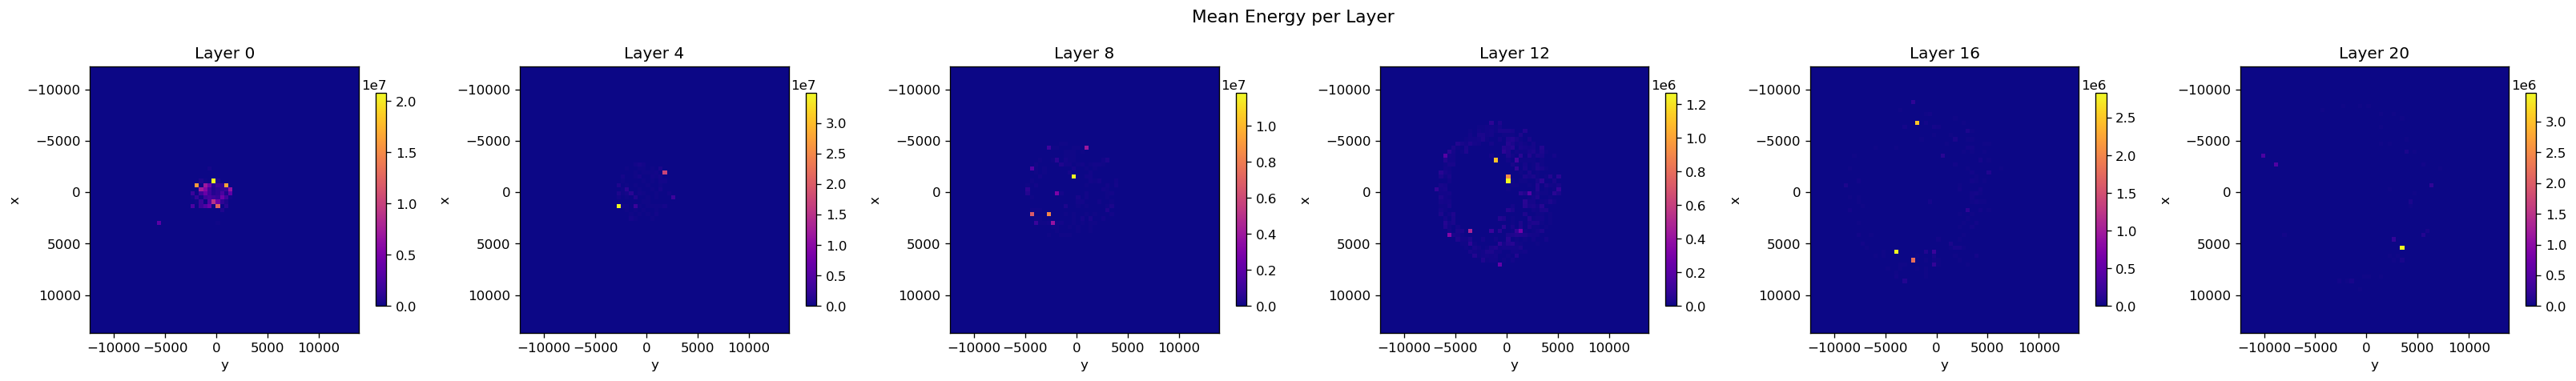

In [34]:
# Show mean energy map for a selection of layers
SHOW_LAYERS = [0, 4, 8, 12, 16, 20]
fig, axes = plt.subplots(1, len(SHOW_LAYERS), figsize=(4.5 * len(SHOW_LAYERS), 4))

for col, lyr_idx in enumerate(SHOW_LAYERS):
    lyr_mask_hits = valid & (pts_lyr == lyr_idx)
    x_l = pts_x[lyr_mask_hits].numpy()
    y_l = pts_y[lyr_mask_hits].numpy()
    e_l = pts_e[lyr_mask_hits].numpy()

    if len(x_l) == 0:
        axes[col].text(0.5, 0.5, 'No hits', ha='center', va='center', transform=axes[col].transAxes)
        axes[col].set_title(f'Layer {lyr_idx}')
        continue

    h, xe, ye = np.histogram2d(x_l, y_l, bins=GRID_RES,
                                range=[[x_lo, x_hi], [y_lo, y_hi]],
                                weights=e_l)
    hn, _, _  = np.histogram2d(x_l, y_l, bins=GRID_RES,
                                range=[[x_lo, x_hi], [y_lo, y_hi]])
    mean_grid = h / np.maximum(hn, 1)

    im = axes[col].imshow(mean_grid, extent=extent, aspect='auto', origin='upper', cmap='plasma')
    fig.colorbar(im, ax=axes[col], shrink=0.8)
    axes[col].set_title(f'Layer {lyr_idx}')
    axes[col].set_xlabel('y'); axes[col].set_ylabel('x')

plt.suptitle('Mean Energy per Layer', fontsize=13)
plt.tight_layout(); plt.show()

## 7. Average Shower by Energy Bins

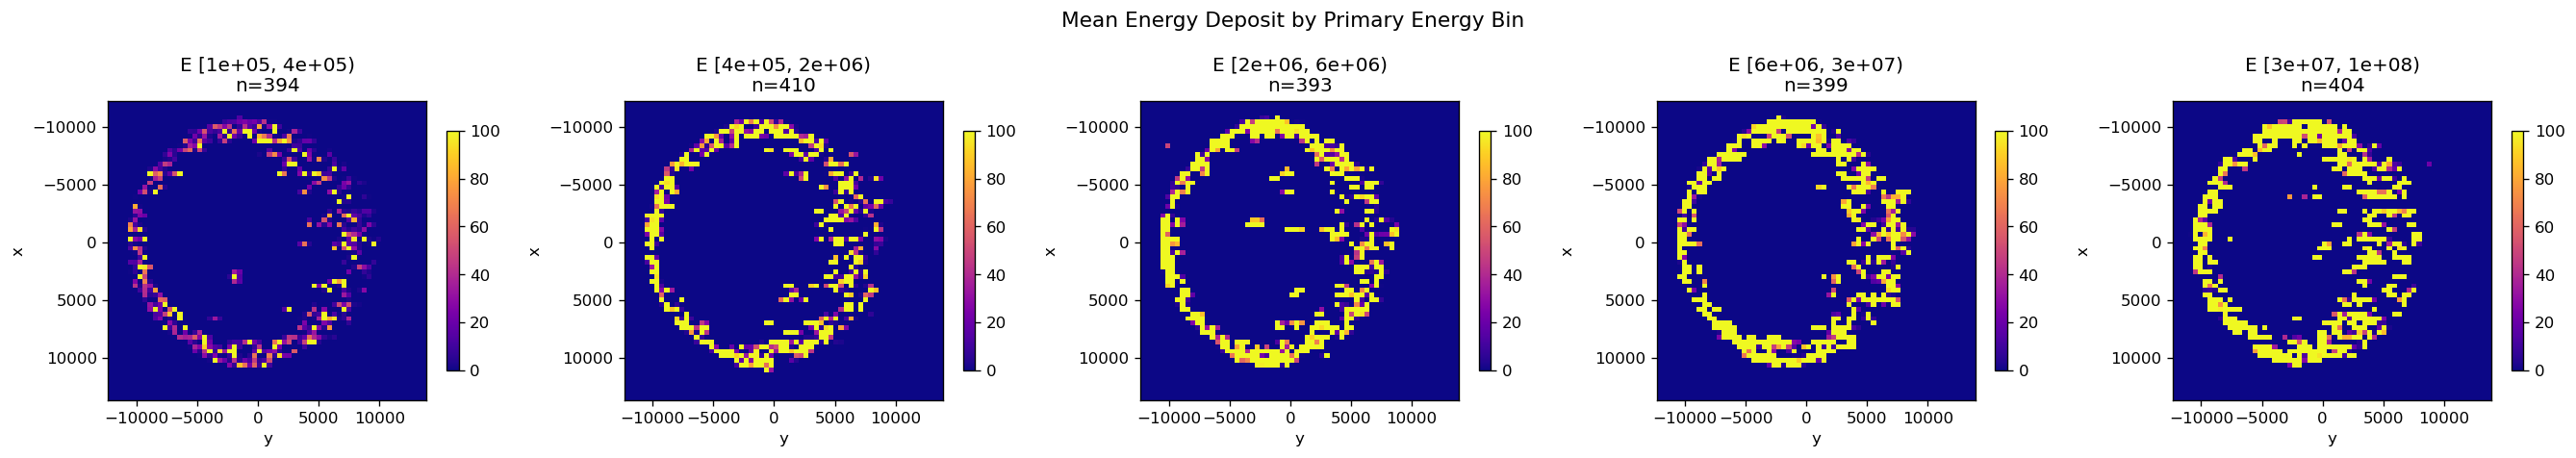

In [61]:
log_e   = torch.log10(p_energy)
PLANE = 20
plane_valid = valid & (pts_lyr == PLANE)

n_bins  = 5
edges   = torch.linspace(log_e.min(), log_e.max(), n_bins + 1)

fig, axes = plt.subplots(1, n_bins, figsize=(4.5 * n_bins, 4))

for b in range(n_bins):
    mask = (log_e >= edges[b]) & (log_e <= edges[b + 1])
    cnt  = mask.sum().item()
    e_lo = 10 ** edges[b].item()
    e_hi = 10 ** edges[b + 1].item()

    if cnt == 0:
        axes[b].text(0.5, 0.5, 'No events', ha='center', va='center', transform=axes[b].transAxes)
        continue

    x_b = pts_x[mask][plane_valid[mask]].numpy()
    y_b = pts_y[mask][plane_valid[mask]].numpy()
    e_b = pts_e[mask][plane_valid[mask]].numpy()
    

    h, _, _ = np.histogram2d(x_b, y_b, bins=GRID_RES,
                              range=[[x_lo, x_hi], [y_lo, y_hi]], weights=e_b)
    hn, _, _ = np.histogram2d(x_b, y_b, bins=GRID_RES,
                               range=[[x_lo, x_hi], [y_lo, y_hi]])
    mean_g = h / np.maximum(hn, 1)

    im = axes[b].imshow(mean_g, extent=extent, aspect='auto', origin='upper', cmap='plasma', vmin=0, vmax=1e2)
    fig.colorbar(im, ax=axes[b], shrink=0.8)
    axes[b].set_title(f'E [{e_lo:.0e}, {e_hi:.0e})\nn={cnt}')
    axes[b].set_xlabel('y'); axes[b].set_ylabel('x')

plt.suptitle('Mean Energy Deposit by Primary Energy Bin', fontsize=13)
plt.tight_layout(); plt.show()

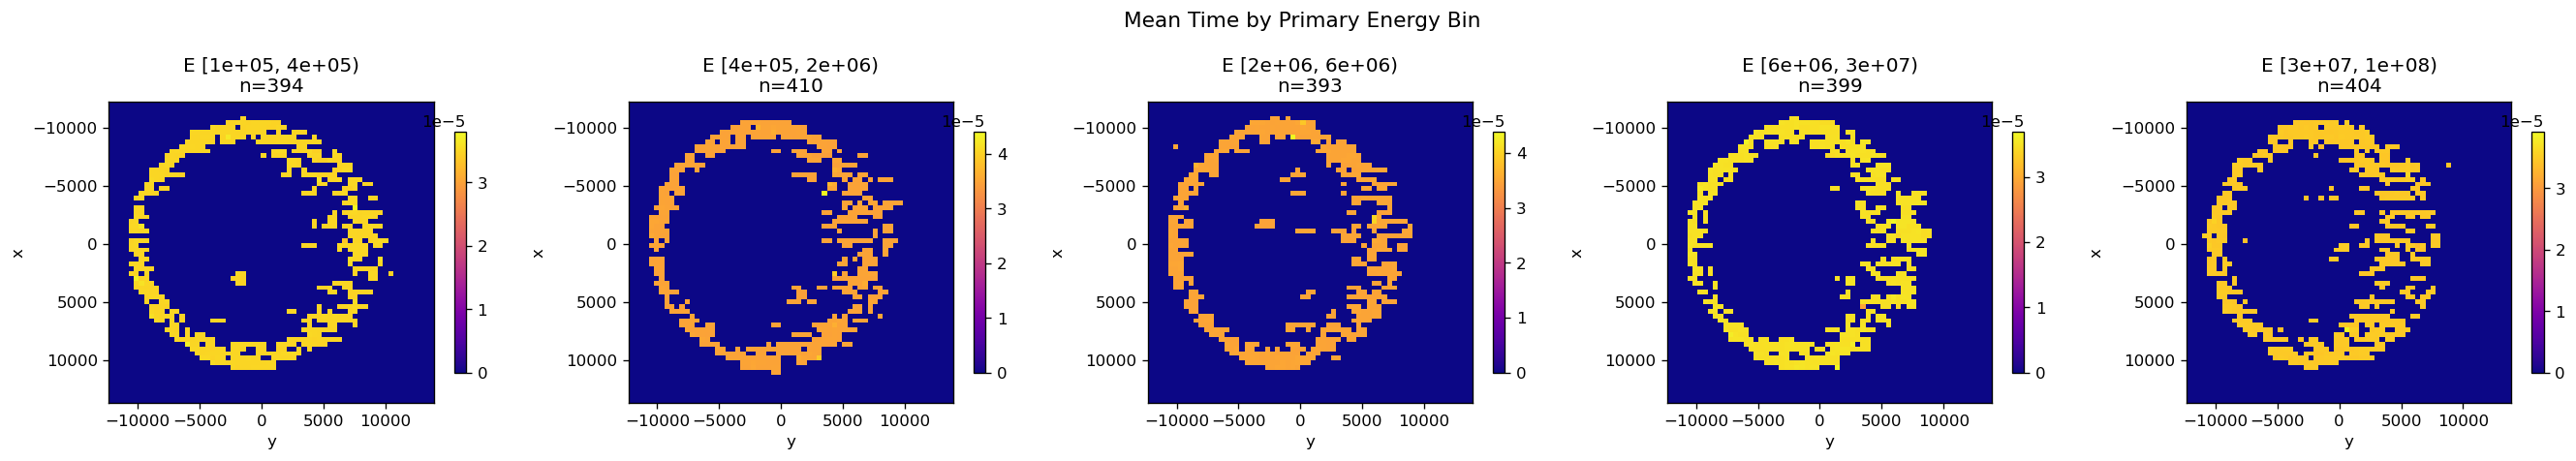

In [58]:
log_e   = torch.log10(p_energy)
PLANE = 20
plane_valid = valid & (pts_lyr == PLANE)

n_bins  = 5
edges   = torch.linspace(log_e.min(), log_e.max(), n_bins + 1)

fig, axes = plt.subplots(1, n_bins, figsize=(4.5 * n_bins, 4))

for b in range(n_bins):
    mask = (log_e >= edges[b]) & (log_e <= edges[b + 1])
    cnt  = mask.sum().item()
    e_lo = 10 ** edges[b].item()
    e_hi = 10 ** edges[b + 1].item()

    if cnt == 0:
        axes[b].text(0.5, 0.5, 'No events', ha='center', va='center', transform=axes[b].transAxes)
        continue

    x_b = pts_x[mask][plane_valid[mask]].numpy()
    y_b = pts_y[mask][plane_valid[mask]].numpy()
    t_b = pts_t[mask][plane_valid[mask]].numpy()

    h, _, _ = np.histogram2d(x_b, y_b, bins=GRID_RES,
                              range=[[x_lo, x_hi], [y_lo, y_hi]], weights=t_b)
    hn, _, _ = np.histogram2d(x_b, y_b, bins=GRID_RES,
                               range=[[x_lo, x_hi], [y_lo, y_hi]])
    mean_g = h / np.maximum(hn, 1)

    im = axes[b].imshow(mean_g, extent=extent, aspect='auto', origin='upper', cmap='plasma')
    fig.colorbar(im, ax=axes[b], shrink=0.8)
    axes[b].set_title(f'E [{e_lo:.0e}, {e_hi:.0e})\nn={cnt}')
    axes[b].set_xlabel('y'); axes[b].set_ylabel('x')

plt.suptitle('Mean Time by Primary Energy Bin', fontsize=13)
plt.tight_layout(); plt.show()

## 8. Average Shower by angle Bins

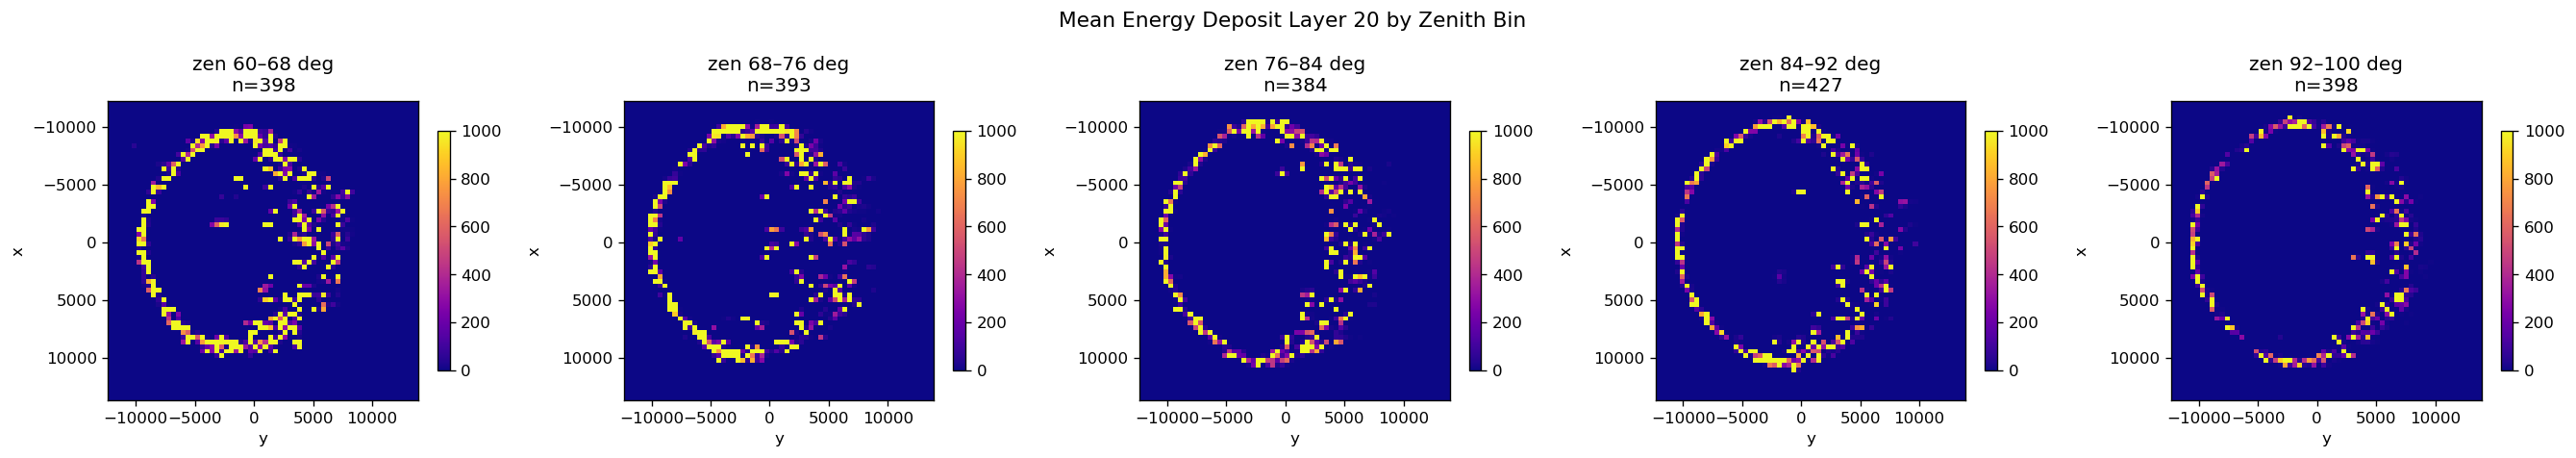

In [48]:
PLANE = 20
plane_valid = valid & (pts_lyr == PLANE)

n_zbins = 5

zen_edges = np.linspace(zenith_deg.min(), zenith_deg.max(), n_zbins + 1)

fig, axes = plt.subplots(1, n_zbins, figsize=(4.5 * n_zbins, 4))

for b in range(n_zbins):
    mask_np = (zenith_deg >= zen_edges[b]) & (zenith_deg <= zen_edges[b + 1])
    mask_t  = torch.from_numpy(mask_np)
    cnt = mask_t.sum().item()

    if cnt == 0:
        axes[b].text(0.5, 0.5, 'No events', ha='center', va='center', transform=axes[b].transAxes)
        continue
    
    x_b = pts_x[mask_t][plane_valid[mask_t]].numpy()
    y_b = pts_y[mask_t][plane_valid[mask_t]].numpy()
    e_b = pts_e[mask_t][plane_valid[mask_t]].numpy()

    h, _, _ = np.histogram2d(x_b, y_b, bins=GRID_RES,
                              range=[[x_lo, x_hi], [y_lo, y_hi]], weights=e_b)
    hn, _, _ = np.histogram2d(x_b, y_b, bins=GRID_RES,
                               range=[[x_lo, x_hi], [y_lo, y_hi]])
    mean_g = h / np.maximum(hn, 1)

    im = axes[b].imshow(mean_g, extent=extent, aspect='auto', origin='upper', cmap='plasma', vmin=0, vmax=1e3)
    fig.colorbar(im, ax=axes[b], shrink=0.8)

    axes[b].set_title(f'zen {zen_edges[b]:.0f}–{zen_edges[b+1]:.0f} deg\nn={cnt}')
    axes[b].set_xlabel('y'); axes[b].set_ylabel('x')

plt.suptitle(f'Mean Energy Deposit Layer {PLANE} by Zenith Bin', fontsize=13)
plt.tight_layout(); plt.show()

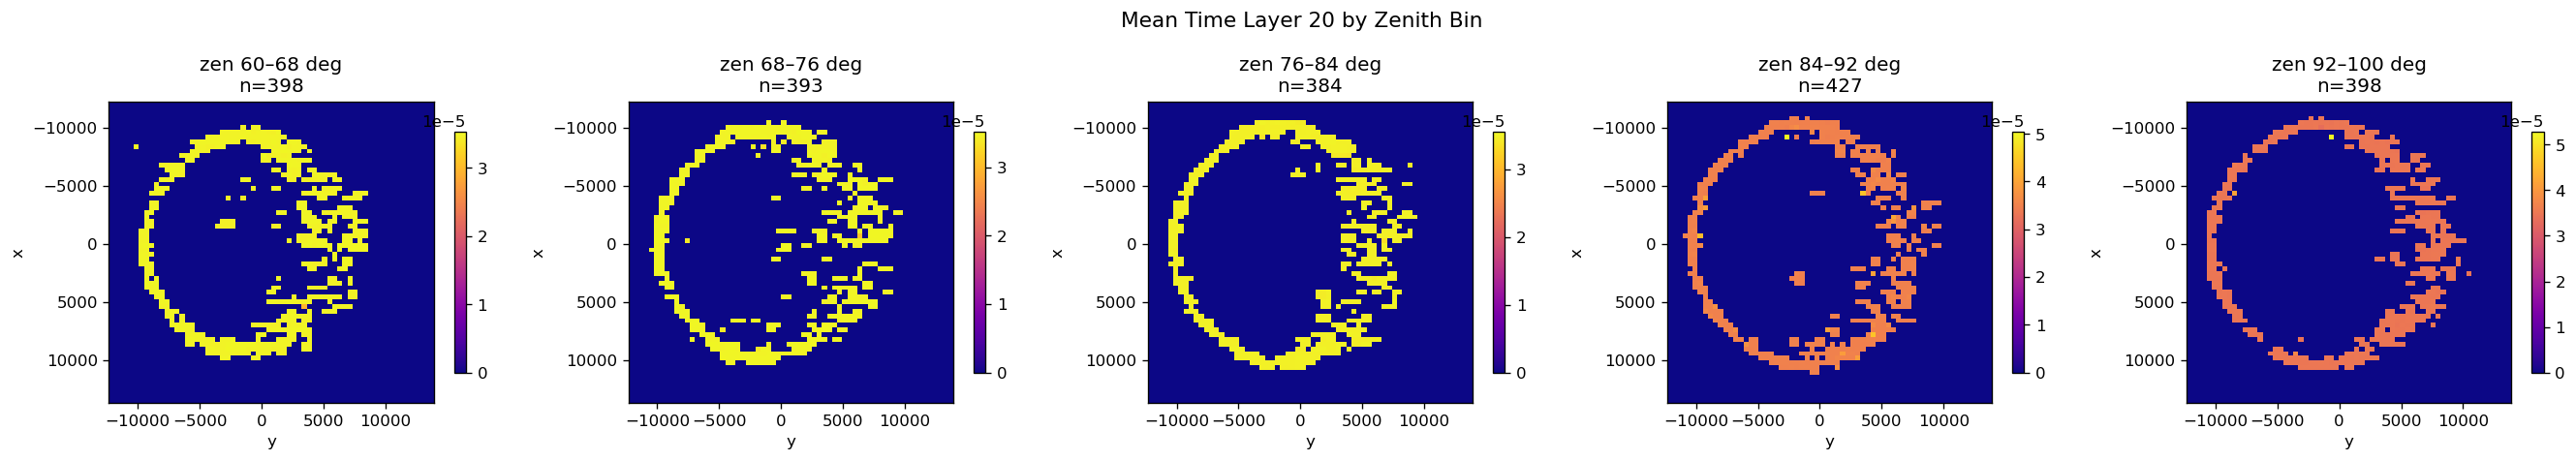

In [56]:
PLANE = 20
plane_valid = valid & (pts_lyr == PLANE)

n_zbins = 5

zen_edges = np.linspace(zenith_deg.min(), zenith_deg.max(), n_zbins + 1)

fig, axes = plt.subplots(1, n_zbins, figsize=(4.5 * n_zbins, 4))

for b in range(n_zbins):
    mask_np = (zenith_deg >= zen_edges[b]) & (zenith_deg <= zen_edges[b + 1])
    mask_t  = torch.from_numpy(mask_np)
    cnt = mask_t.sum().item()

    if cnt == 0:
        axes[b].text(0.5, 0.5, 'No events', ha='center', va='center', transform=axes[b].transAxes)
        continue
    
    x_b = pts_x[mask_t][plane_valid[mask_t]].numpy()
    y_b = pts_y[mask_t][plane_valid[mask_t]].numpy()
    t_b = pts_t[mask_t][plane_valid[mask_t]].numpy()

    h, _, _ = np.histogram2d(x_b, y_b, bins=GRID_RES,
                              range=[[x_lo, x_hi], [y_lo, y_hi]], weights=t_b)
    hn, _, _ = np.histogram2d(x_b, y_b, bins=GRID_RES,
                               range=[[x_lo, x_hi], [y_lo, y_hi]])
    mean_g = h / np.maximum(hn, 1)

    im = axes[b].imshow(mean_g, extent=extent, aspect='auto', origin='upper', cmap='plasma')
    fig.colorbar(im, ax=axes[b], shrink=0.8)

    axes[b].set_title(f'zen {zen_edges[b]:.0f}–{zen_edges[b+1]:.0f} deg\nn={cnt}')
    axes[b].set_xlabel('y'); axes[b].set_ylabel('x')

plt.suptitle(f'Mean Time Layer {PLANE} by Zenith Bin', fontsize=13)
plt.tight_layout(); plt.show()

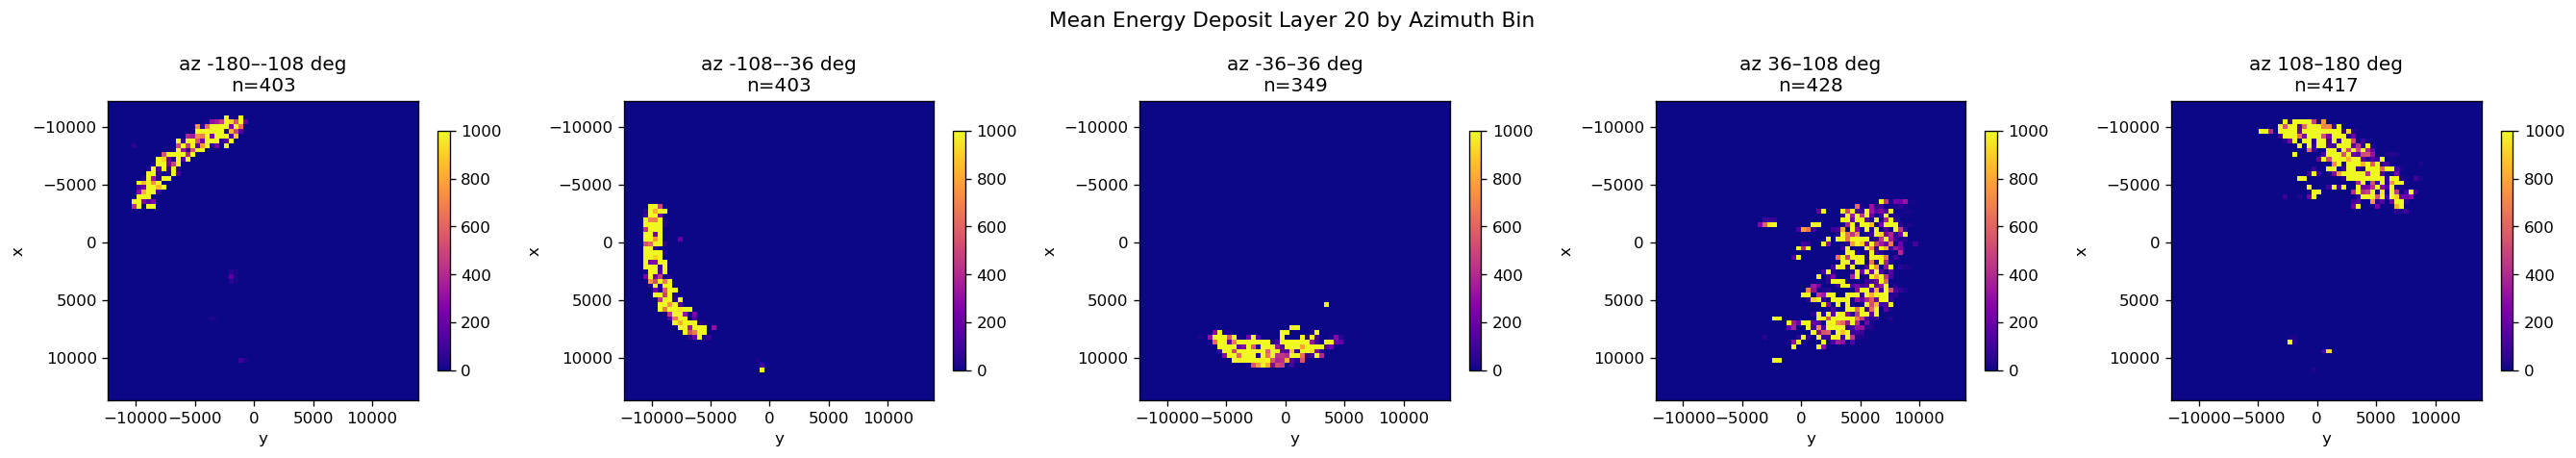

In [46]:
PLANE = 20
plane_valid = valid & (pts_lyr == PLANE)

n_zbins = 5

az_edges = np.linspace(azimuth_deg.min(), azimuth_deg.max(), n_zbins + 1)

fig, axes = plt.subplots(1, n_zbins, figsize=(4.5 * n_zbins, 4))

for b in range(n_zbins):
    mask_np = (azimuth_deg >= az_edges[b]) & (azimuth_deg <= az_edges[b + 1])
    mask_t  = torch.from_numpy(mask_np)
    cnt = mask_t.sum().item()

    if cnt == 0:
        axes[b].text(0.5, 0.5, 'No events', ha='center', va='center', transform=axes[b].transAxes)
        continue
    
    x_b = pts_x[mask_t][plane_valid[mask_t]].numpy()
    y_b = pts_y[mask_t][plane_valid[mask_t]].numpy()
    e_b = pts_e[mask_t][plane_valid[mask_t]].numpy()

    h, _, _ = np.histogram2d(x_b, y_b, bins=GRID_RES,
                              range=[[x_lo, x_hi], [y_lo, y_hi]], weights=e_b)
    hn, _, _ = np.histogram2d(x_b, y_b, bins=GRID_RES,
                               range=[[x_lo, x_hi], [y_lo, y_hi]])
    mean_g = h / np.maximum(hn, 1)

    im = axes[b].imshow(mean_g, extent=extent, aspect='auto', origin='upper', cmap='plasma', vmin=0, vmax=1e3)
    fig.colorbar(im, ax=axes[b], shrink=0.8)

    axes[b].set_title(f'az {az_edges[b]:.0f}–{az_edges[b+1]:.0f} deg\nn={cnt}')
    axes[b].set_xlabel('y'); axes[b].set_ylabel('x')

plt.suptitle(f'Mean Energy Deposit Layer {PLANE} by Azimuth Bin', fontsize=13)
plt.tight_layout(); plt.show()

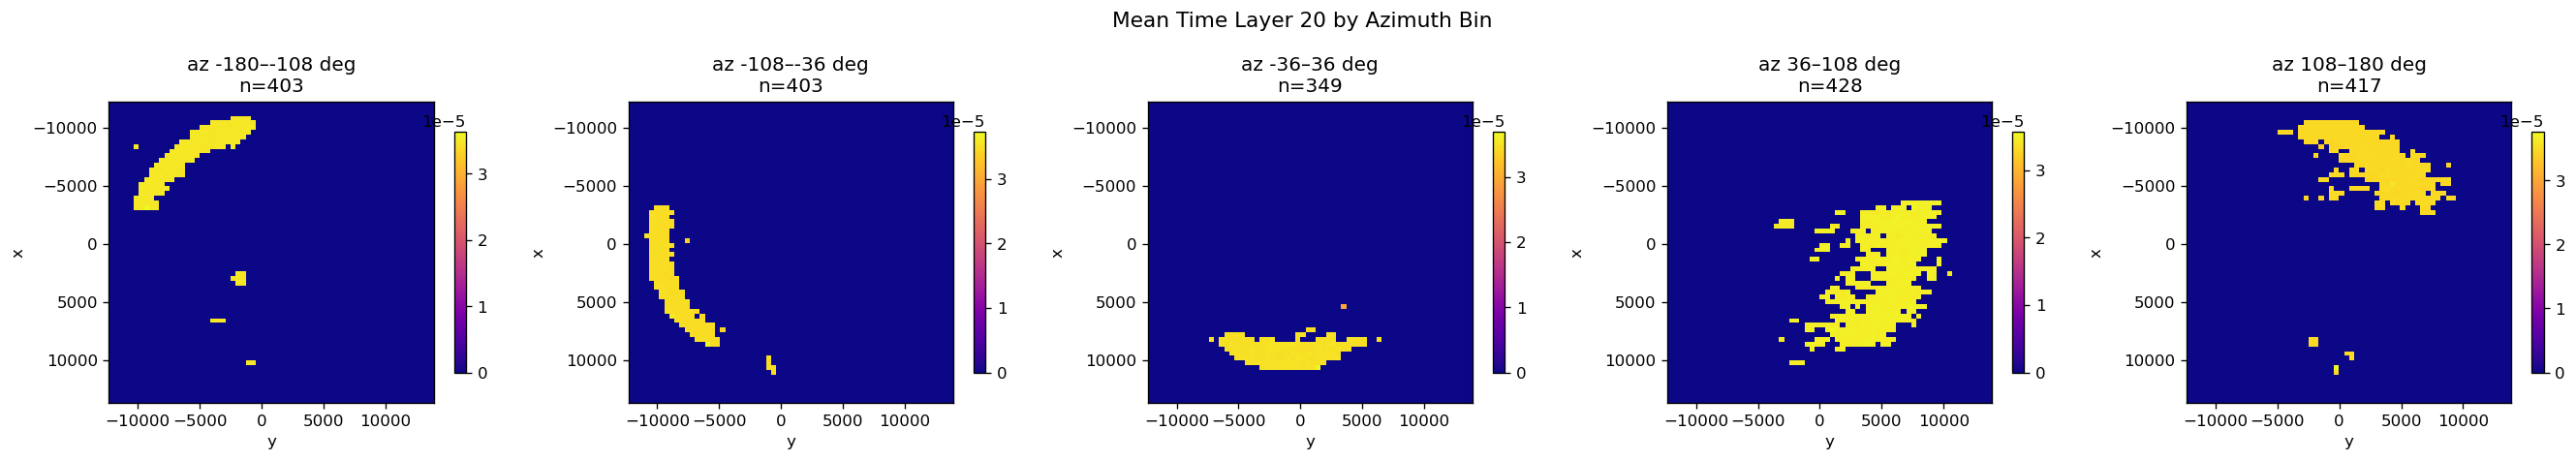

In [57]:
PLANE = 20
plane_valid = valid & (pts_lyr == PLANE)

n_zbins = 5

az_edges = np.linspace(azimuth_deg.min(), azimuth_deg.max(), n_zbins + 1)

fig, axes = plt.subplots(1, n_zbins, figsize=(4.5 * n_zbins, 4))

for b in range(n_zbins):
    mask_np = (azimuth_deg >= az_edges[b]) & (azimuth_deg <= az_edges[b + 1])
    mask_t  = torch.from_numpy(mask_np)
    cnt = mask_t.sum().item()

    if cnt == 0:
        axes[b].text(0.5, 0.5, 'No events', ha='center', va='center', transform=axes[b].transAxes)
        continue
    
    x_b = pts_x[mask_t][plane_valid[mask_t]].numpy()
    y_b = pts_y[mask_t][plane_valid[mask_t]].numpy()
    t_b = pts_t[mask_t][plane_valid[mask_t]].numpy()

    h, _, _ = np.histogram2d(x_b, y_b, bins=GRID_RES,
                              range=[[x_lo, x_hi], [y_lo, y_hi]], weights=t_b)
    hn, _, _ = np.histogram2d(x_b, y_b, bins=GRID_RES,
                               range=[[x_lo, x_hi], [y_lo, y_hi]])
    mean_g = h / np.maximum(hn, 1)

    im = axes[b].imshow(mean_g, extent=extent, aspect='auto', origin='upper', cmap='plasma')
    fig.colorbar(im, ax=axes[b], shrink=0.8)

    axes[b].set_title(f'az {az_edges[b]:.0f}–{az_edges[b+1]:.0f} deg\nn={cnt}')
    axes[b].set_xlabel('y'); axes[b].set_ylabel('x')

plt.suptitle(f'Mean Time Layer {PLANE} by Azimuth Bin', fontsize=13)
plt.tight_layout(); plt.show()

## 9. Hit Energy & Time Distributions

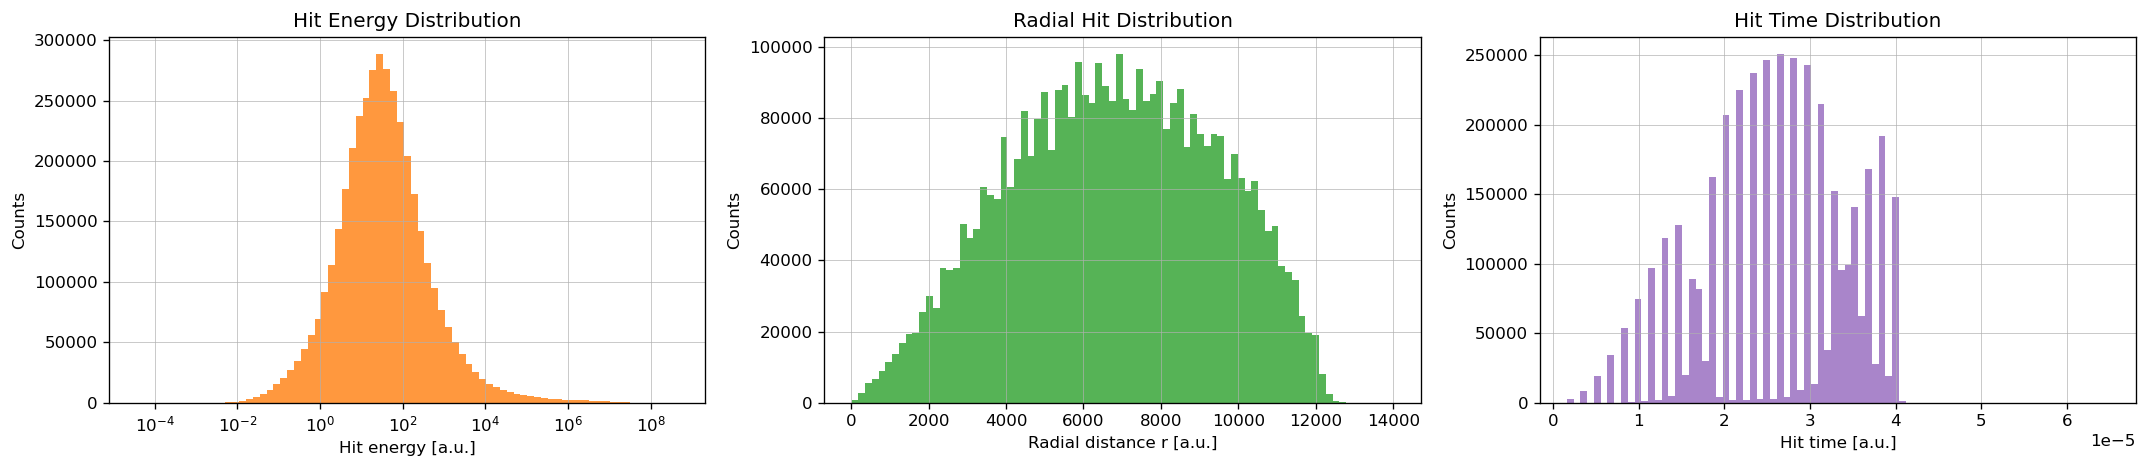

In [37]:
ncols = 3 if with_time else 2
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 4))

e_all = pts_e[valid].numpy()
bins_e = np.logspace(np.log10(max(e_all.min(), 1e-12)), np.log10(e_all.max()), 80)
axes[0].hist(e_all, bins=bins_e, color='C1', alpha=0.8)
axes[0].set_xscale('log'); axes[0].set_xlabel('Hit energy [a.u.]')
axes[0].set_ylabel('Counts'); axes[0].set_title('Hit Energy Distribution')
axes[0].grid(lw=0.4)

# Radial distance from origin
r_all = np.sqrt(pts_x[valid].numpy()**2 + pts_y[valid].numpy()**2)
axes[1].hist(r_all, bins=80, color='C2', alpha=0.8)
axes[1].set_xlabel('Radial distance r [a.u.]'); axes[1].set_ylabel('Counts')
axes[1].set_title('Radial Hit Distribution'); axes[1].grid(lw=0.4)

if with_time:
    t_all = pts_t[valid].numpy()
    axes[2].hist(t_all, bins=80, color='C4', alpha=0.8)
    axes[2].set_xlabel('Hit time [a.u.]'); axes[2].set_ylabel('Counts')
    axes[2].set_title('Hit Time Distribution'); axes[2].grid(lw=0.4)

plt.tight_layout(); plt.show()

## 10. Total Signal vs Primary Energy & Zenith

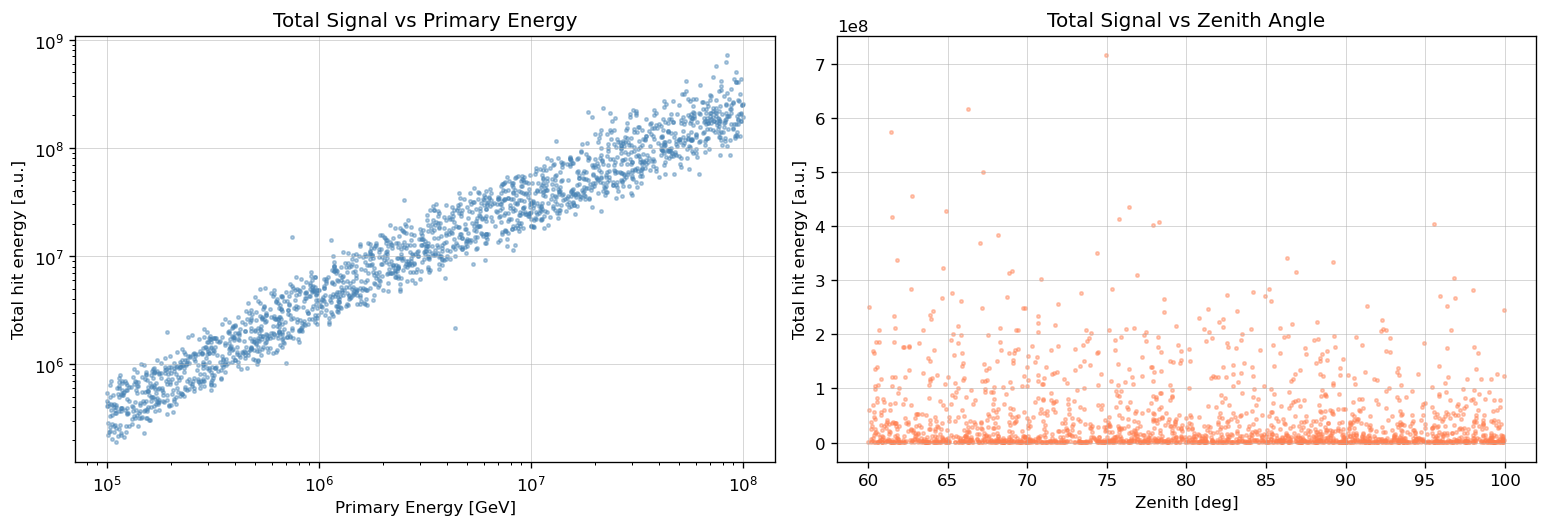

In [38]:
total_e = pts_e.sum(dim=1).numpy()  # sum over all (valid + zero-padded) hits

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(p_energy.numpy(), total_e, s=4, alpha=0.4, color='steelblue')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('Primary Energy [GeV]'); axes[0].set_ylabel('Total hit energy [a.u.]')
axes[0].set_title('Total Signal vs Primary Energy'); axes[0].grid(lw=0.3)

axes[1].scatter(zenith_deg, total_e, s=4, alpha=0.4, color='coral')
axes[1].set_xlabel('Zenith [deg]'); axes[1].set_ylabel('Total hit energy [a.u.]')
axes[1].set_title('Total Signal vs Zenith Angle'); axes[1].grid(lw=0.3)

plt.tight_layout(); plt.show()